This is a short code example (that I've borrowed from StackOverflow regarding questions about using rpy2) that uses R magic in rpy2 in Jupyter notebook with pandas and ggplot2, and most importantly, I've finally figured out how to display the plot as a cell output! I've had to make a few tweaks to the code so this version of code differs from several answers found in SO from quite a number of years ago. 

Overall, my impression of rpy2 so far is that it's a little harder to use than reticulate and due to its ongoing code base improvements and issues, there will always be new or existing bugs... Another thing is that I've found documentations for reticulate somewhat better than rpy2 as I've had to go various different places online to look for answers when using rpy2 (yes, I didn't use any AI agents while working on this... was thinking of it as my last resort but figured it out before I needed to go to that step).

This notebook is also based on a uv venv set up in Python 3.12.7 with rpy2 version 3.6.4 (tried showing rpy2 version as code cell output but apparently this is not available for this version of rpy2 (?) as an error message is produced).

In [2]:
# Hide warnings if there are any
import warnings
warnings.filterwarnings('ignore')

# Load in the r magic
%load_ext rpy2.ipython

Error importing in API mode: ImportError('dlopen(/Users/jenniferlin/Back_to_basics/btb_venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): symbol not found in flat namespace (_R_BaseEnv)')
Trying to import in ABI mode.


In [3]:
# Load in the pandas library
import pandas as pd
# Make a pandas DataFrame
df = pd.DataFrame({'Alphabet': ['a', 'b', 'c', 'd','e', 'f', 'g', 'h','i'],
                   'A': [4, 3, 5, 2, 1, 7, 7, 5, 9],
                   'B': [0, 4, 3, 6, 7, 10, 11, 9, 13],
                   'C': [1, 2, 3, 1, 2, 3, 1, 2, 3]})
df.head()

,Alphabet,A,B,C
0,a,4,0,1
1,b,3,4,2
2,c,5,3,3
3,d,2,6,1
4,e,1,7,2


Loading required package: ggplot2


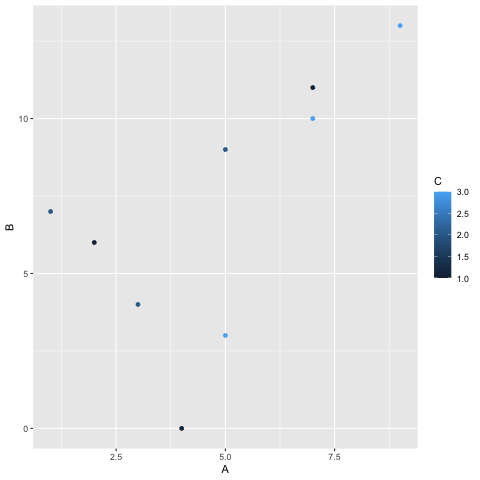

In [4]:
from rpy2.robjects import conversion, default_converter
with conversion.localconverter(default_converter):
    
    # We need ggplot2
    %R require(ggplot2)

    # Take the name of input variable df and assign it to an R variable of the same name
    %R -i df

    # Plot the DataFrame df
    %R print(ggplot(data=df) + geom_point(aes(x=A, y=B, color=C)))

    ## Plot is finally shown!